In [186]:
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots


# DATASET: PREÇO

array([<Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>], dtype=object)

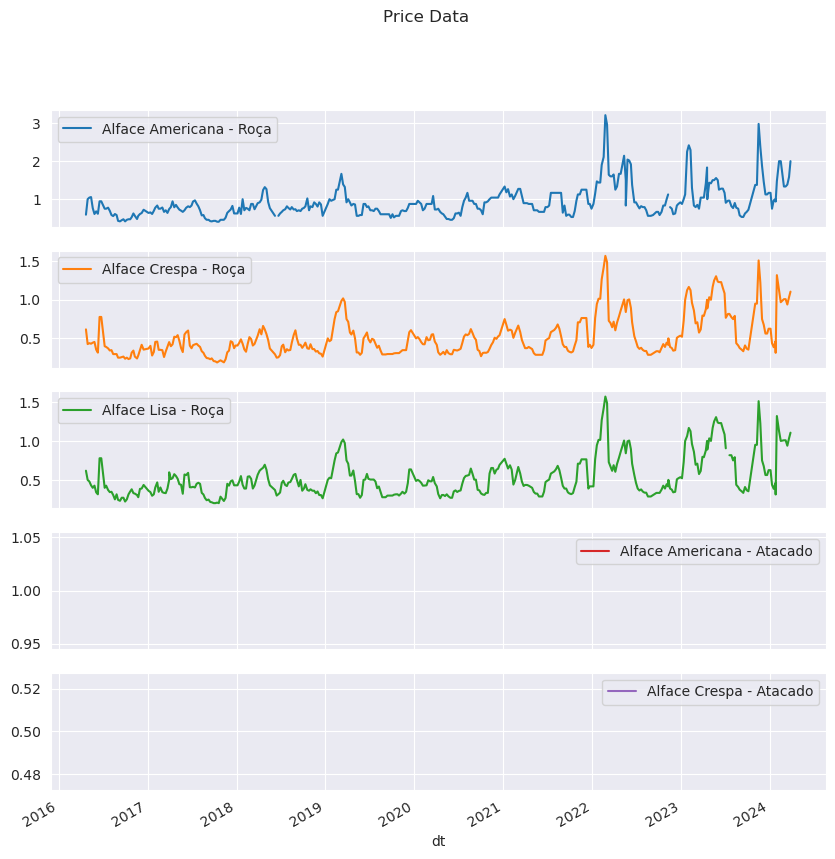

In [187]:
price_df = pd.read_csv('../../processed_data/prices-2016-2024.csv', index_col='dt', parse_dates=True)
price_df.plot(subplots=True, figsize=(10, 10), title='Price Data')



In [188]:
#count the number of NaN values in each column
price_nan_df = pd.DataFrame(price_df.isna().sum().sort_values(ascending=False))
price_nan_df.columns = ['Ausentes']
#rename index
price_nan_df.index.name = 'Coluna'
price_nan_df['% Ausentes'] = price_nan_df['Ausentes'] / len(price_df) * 100
price_nan_df

,Ausentes,% Ausentes
Coluna,,
Alface Americana - Atacado,398,99.749373
Alface Crespa - Atacado,398,99.749373
Alface Americana - Roça,2,0.501253
Alface Lisa - Roça,1,0.250627
Alface Crespa - Roça,0,0.000000


# DATASET: CLIMA

In [189]:
weather_df = pd.read_csv('../../processed_data/weather_2016_2023.csv', index_col='dt', parse_dates=True)
weather_df.drop(columns=['x'], inplace=True)

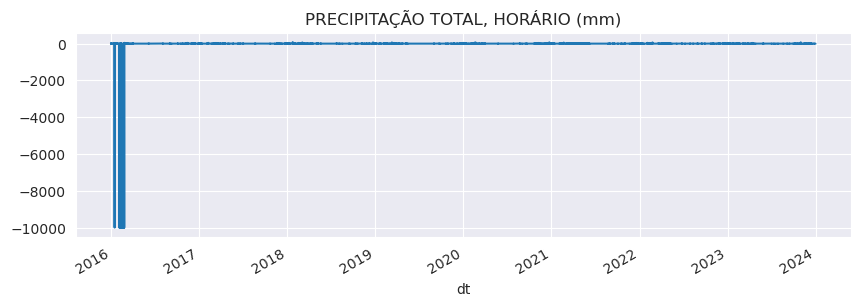

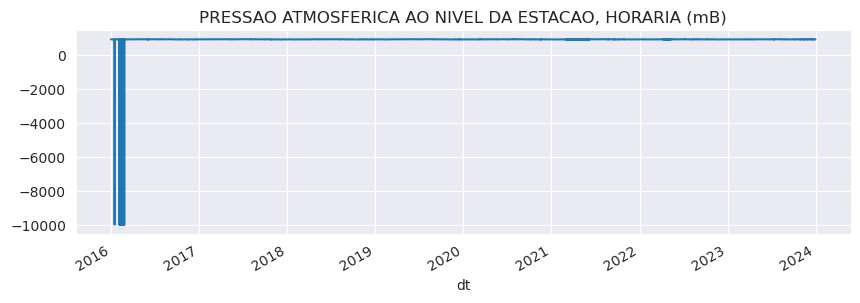

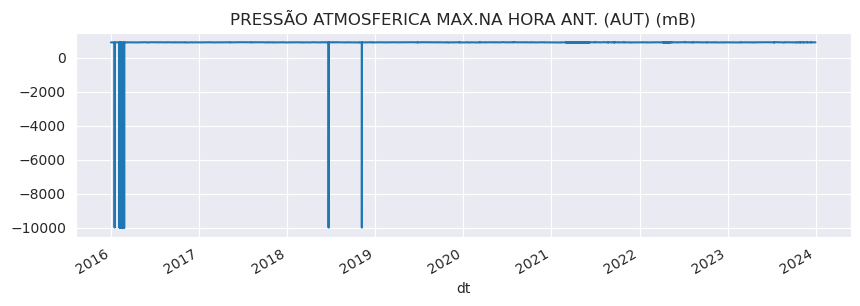

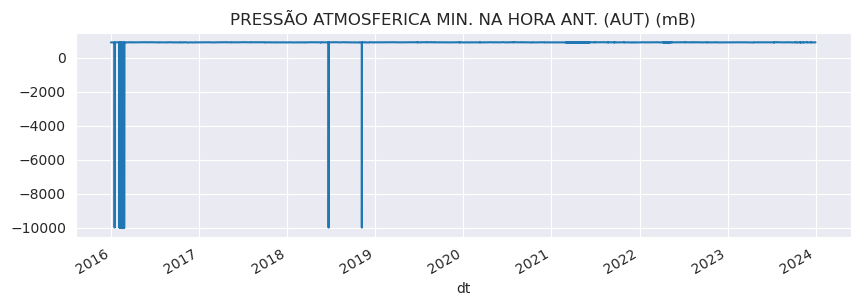

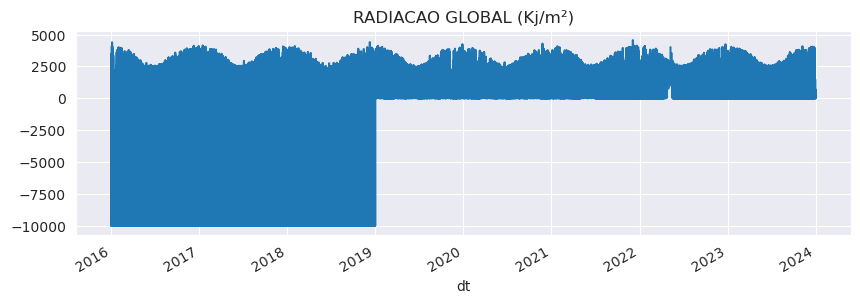

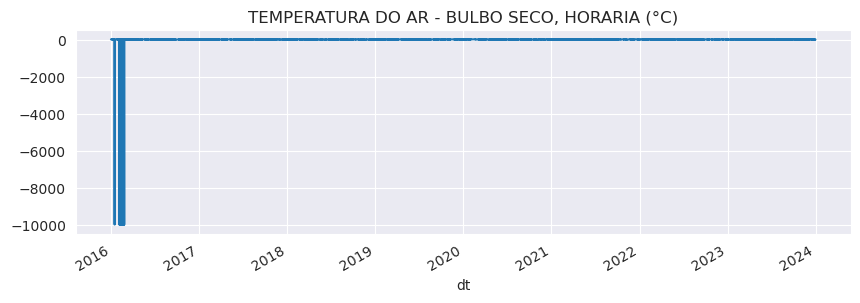

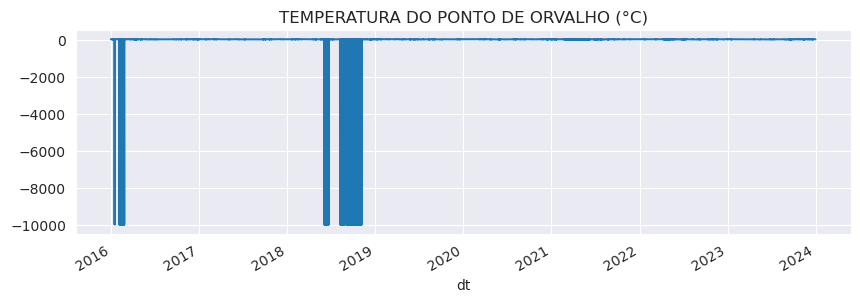

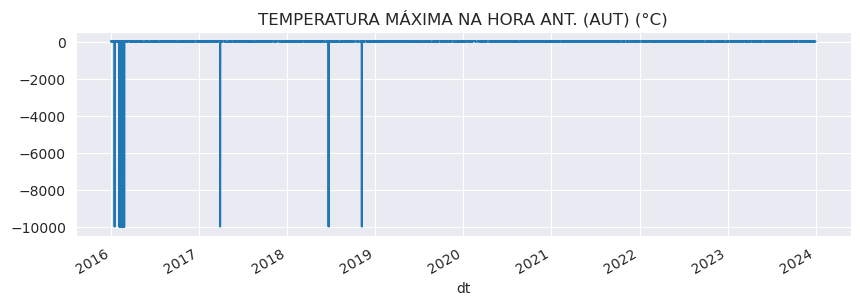

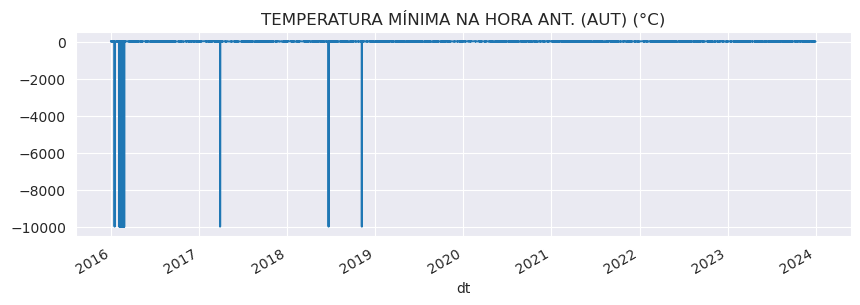

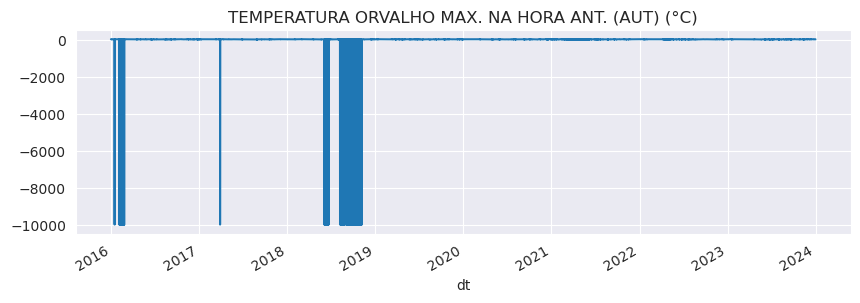

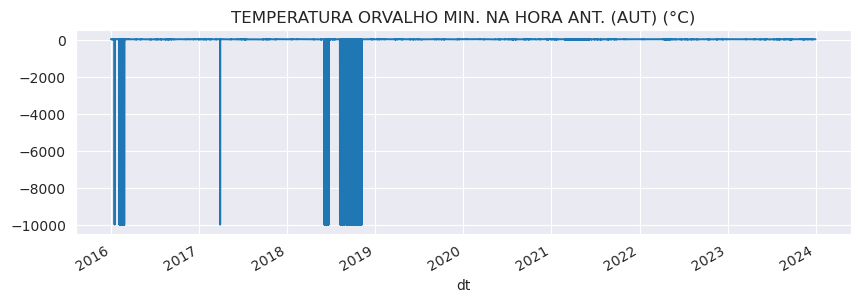

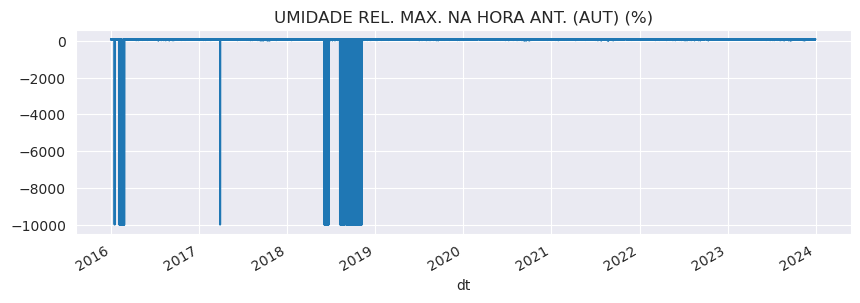

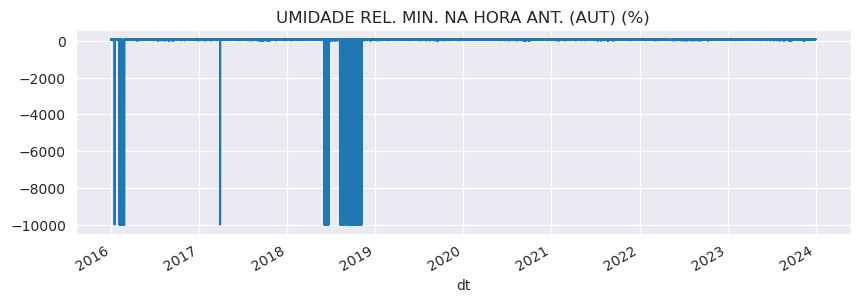

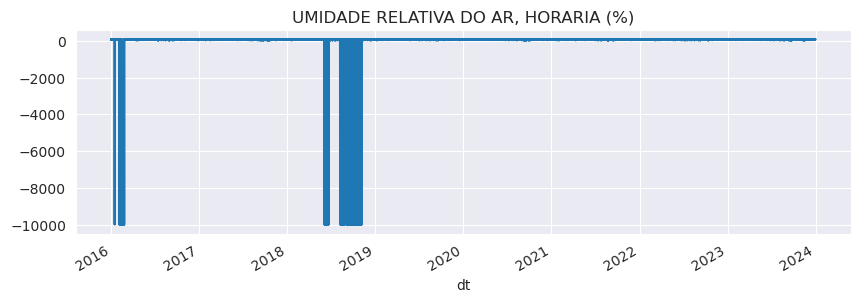

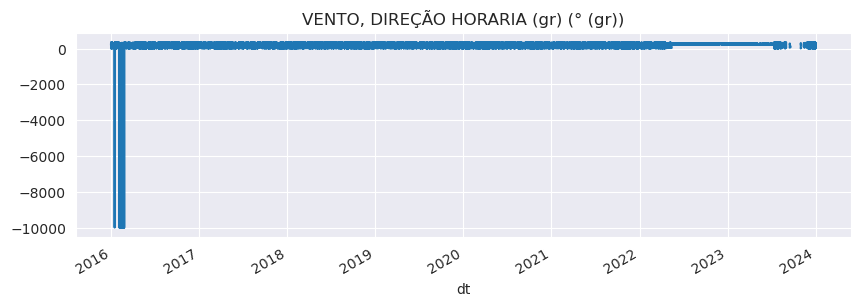

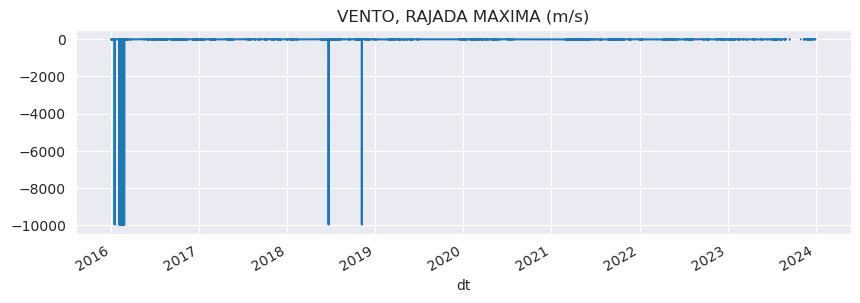

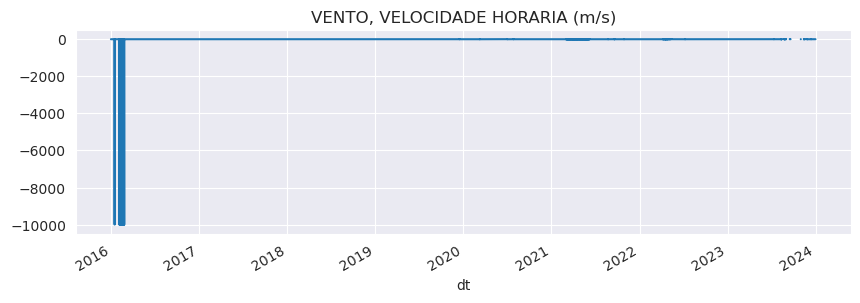

In [190]:
for col in weather_df.columns:
    weather_df[col].plot(figsize=(10, 3), title=col)
    plt.show()


In [191]:
"""
['Alface Americana - Roça',
 'Alface Crespa - Roça',
 'Alface Lisa - Roça',
 'Alface Americana - Atacado',
 'Alface Crespa - Atacado',
 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
 'RADIACAO GLOBAL (Kj/m²)',
 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
 'TEMPERATURA DO PONTO DE ORVALHO (°C)',
 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
 'UMIDADE RELATIVA DO AR, HORARIA (%)',
 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))',
 'VENTO, RAJADA MAXIMA (m/s)',
 'VENTO, VELOCIDADE HORARIA (m/s)']
"""

"\n['Alface Americana - Roça',\n 'Alface Crespa - Roça',\n 'Alface Lisa - Roça',\n 'Alface Americana - Atacado',\n 'Alface Crespa - Atacado',\n 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',\n 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',\n 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',\n 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',\n 'RADIACAO GLOBAL (Kj/m²)',\n 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',\n 'TEMPERATURA DO PONTO DE ORVALHO (°C)',\n 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',\n 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',\n 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',\n 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',\n 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',\n 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',\n 'UMIDADE RELATIVA DO AR, HORARIA (%)',\n 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))',\n 'VENTO, RAJADA MAXIMA (m/s)',\n 'VENTO, VELOCIDADE HORARIA (m/s)']\n"

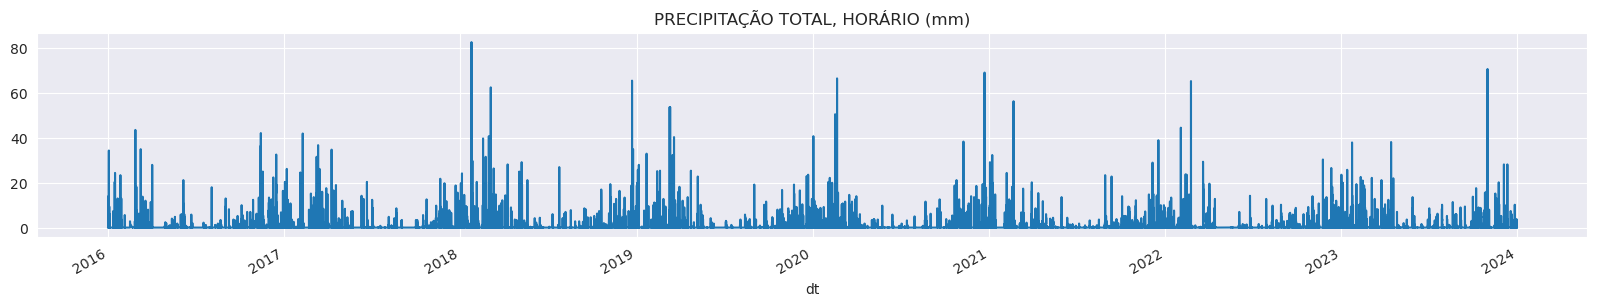

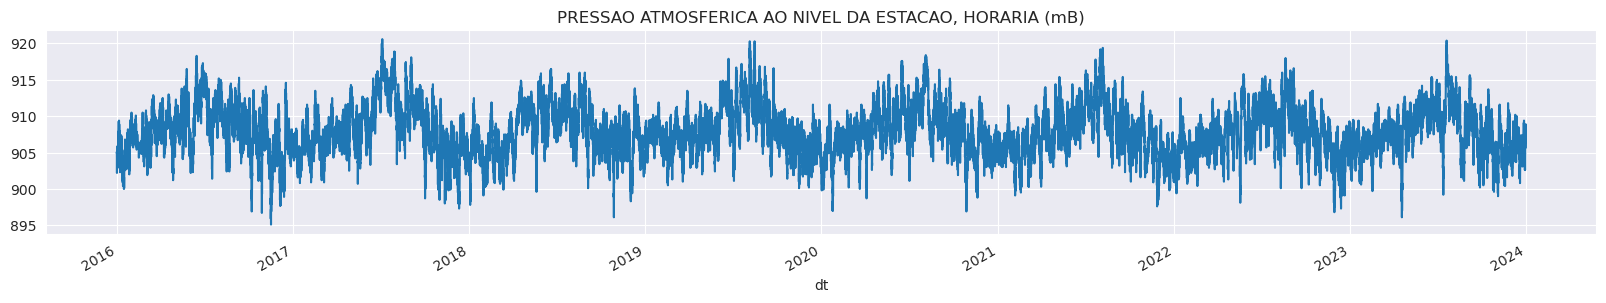

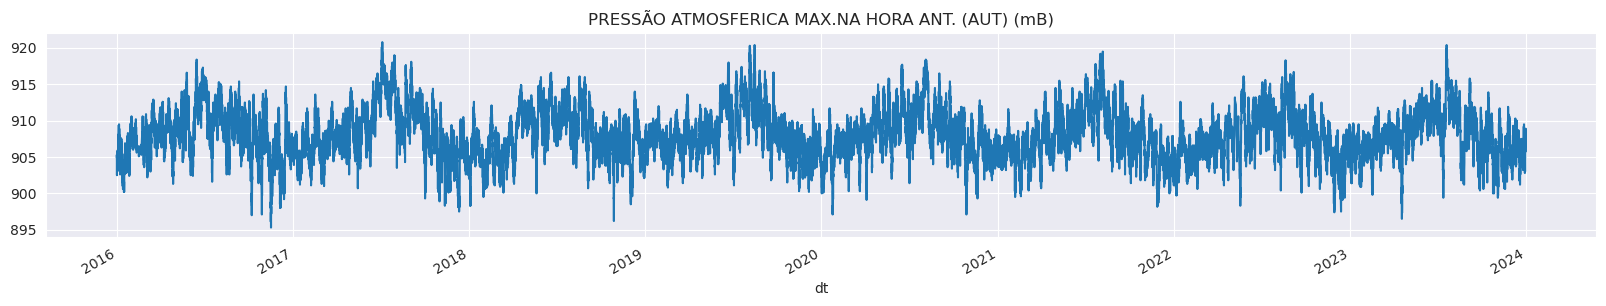

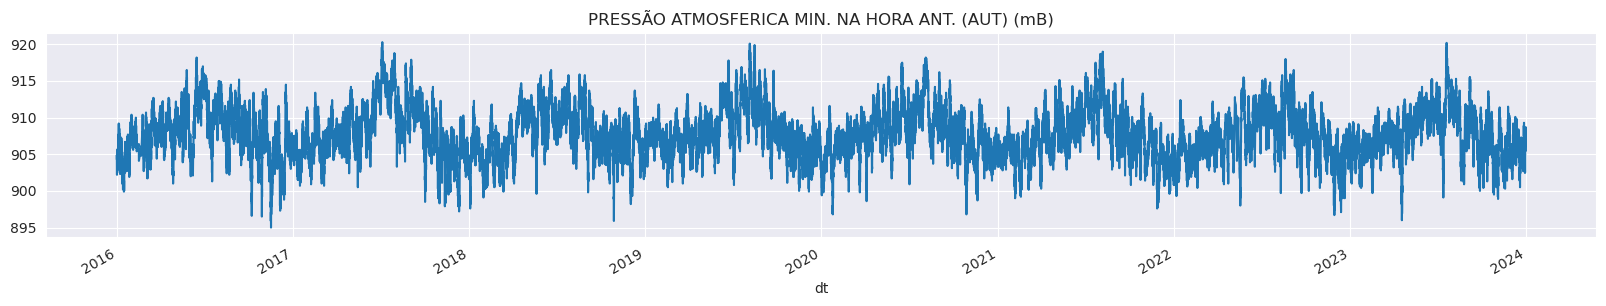

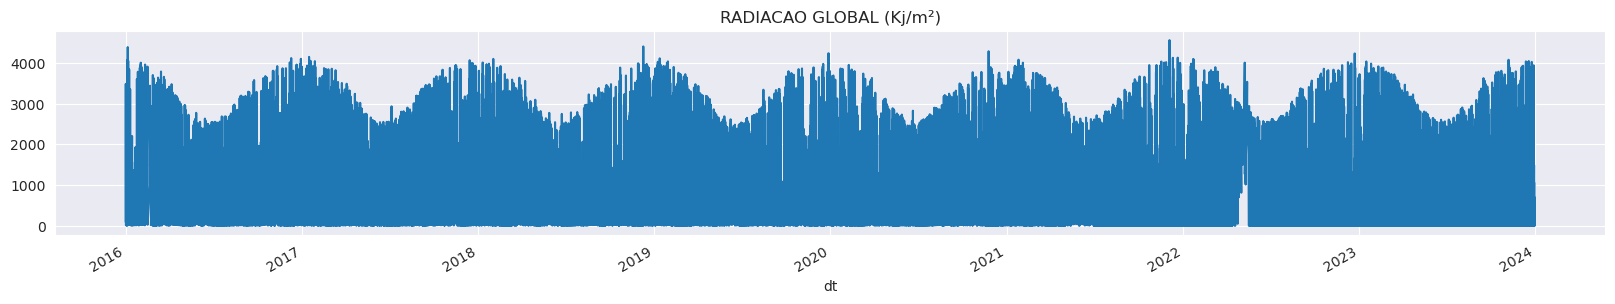

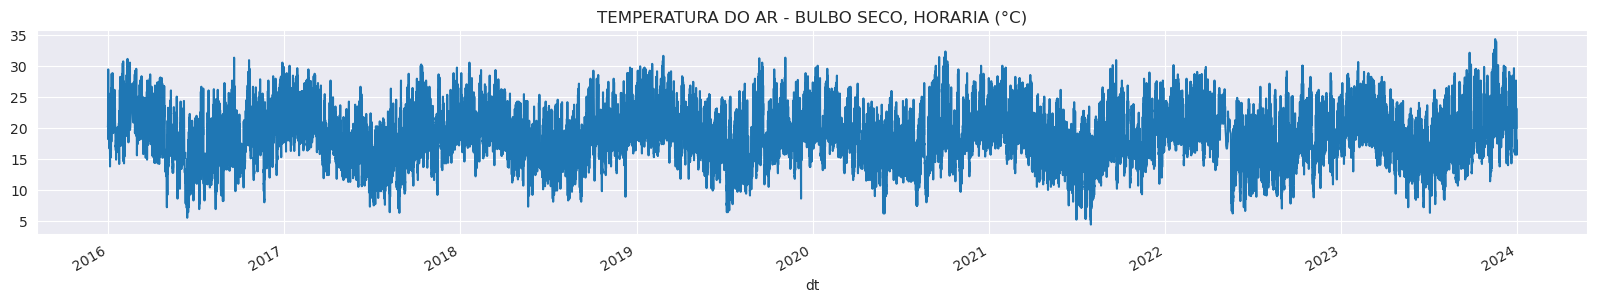

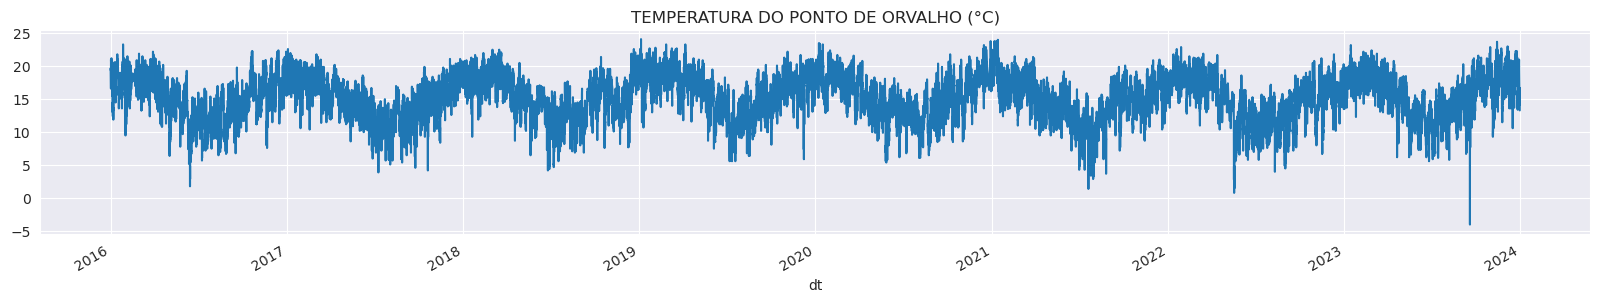

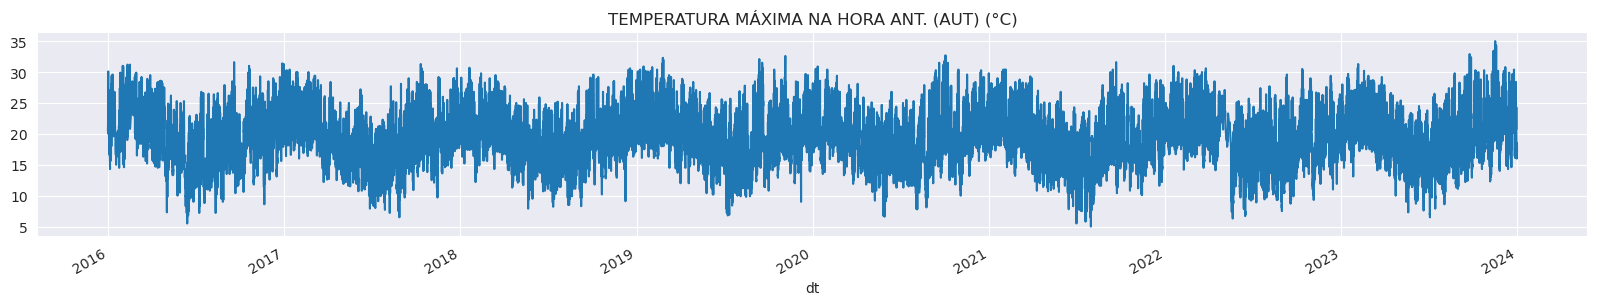

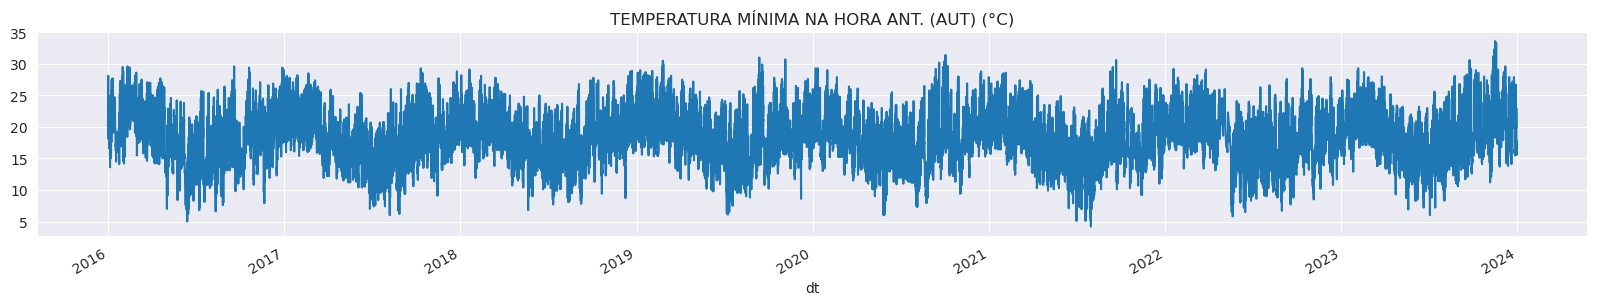

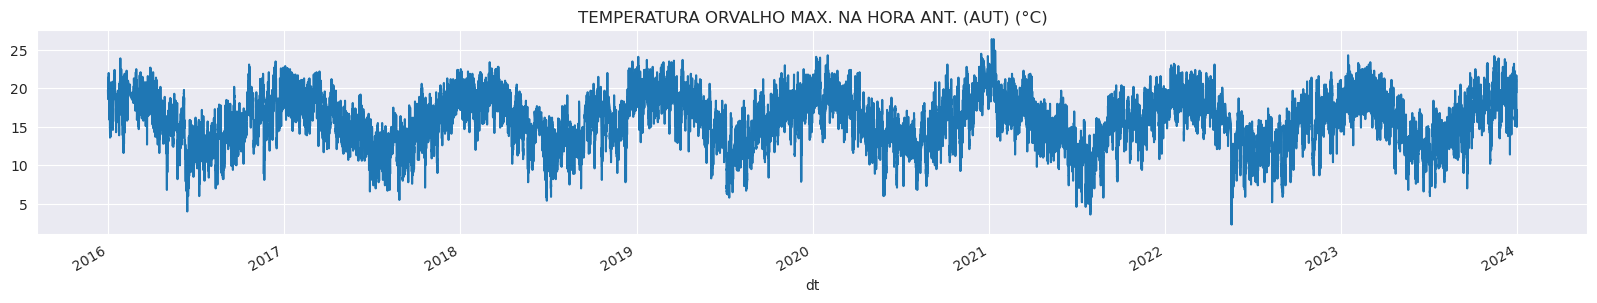

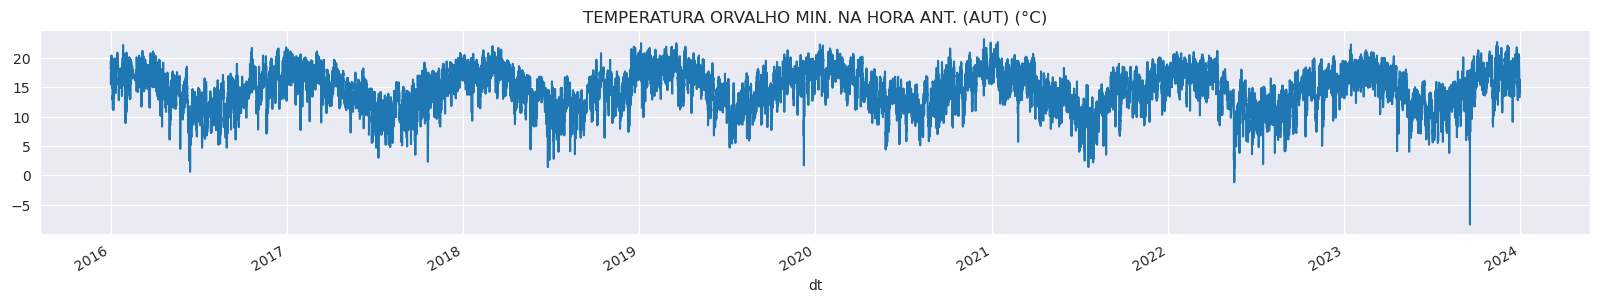

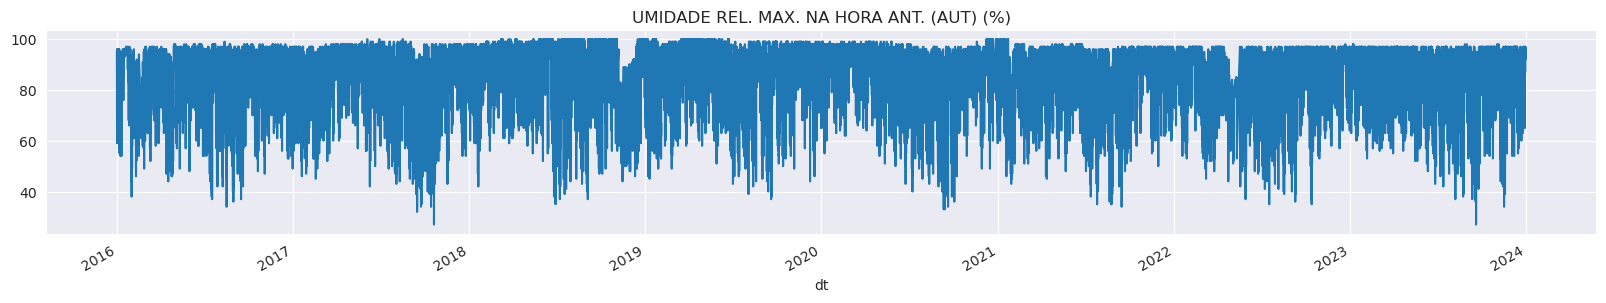

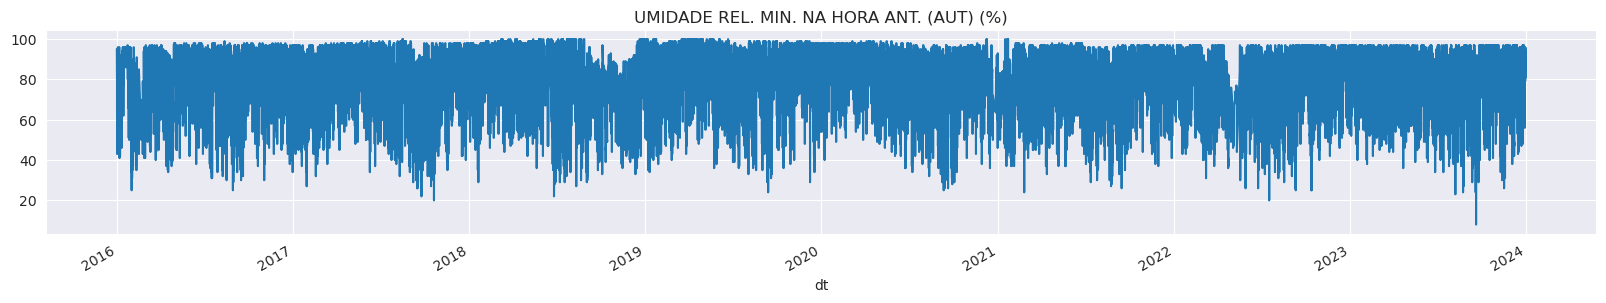

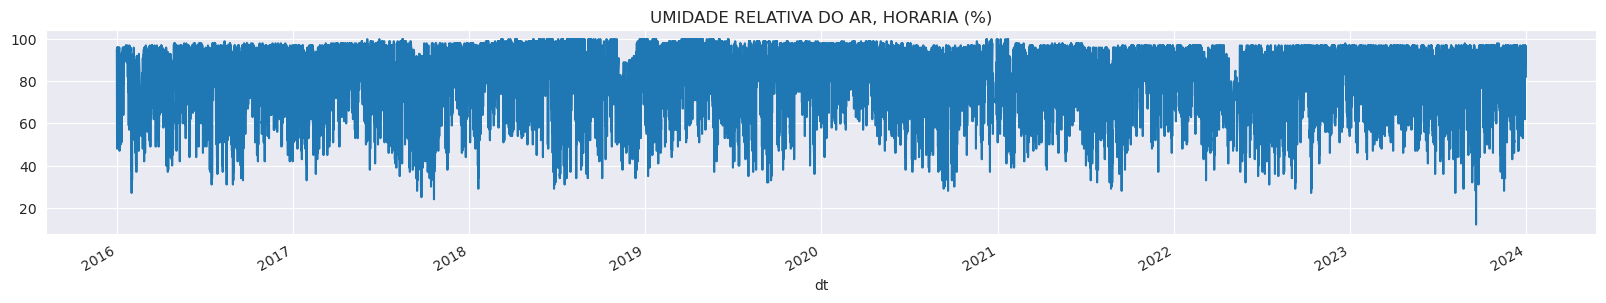

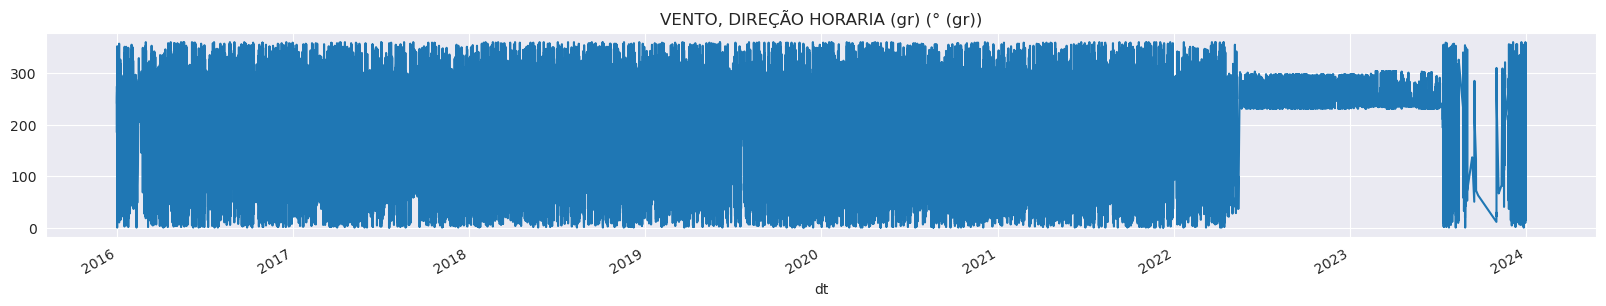

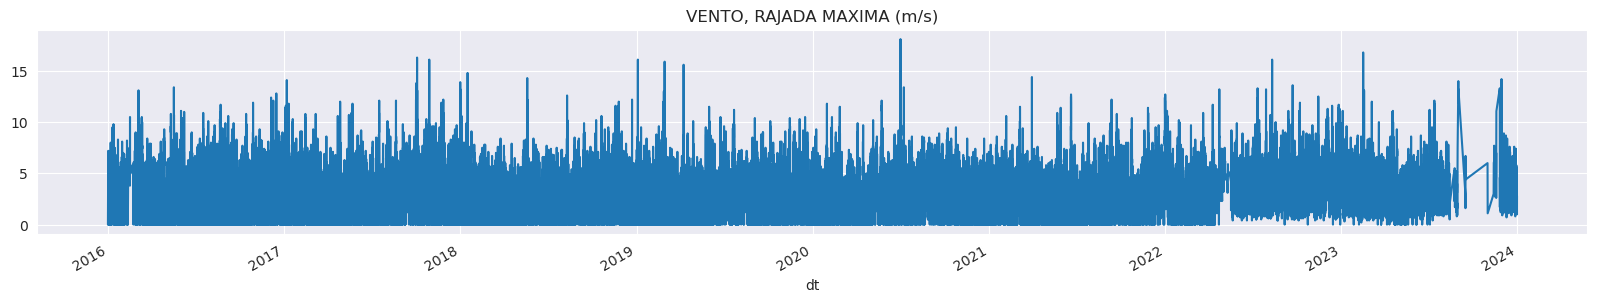

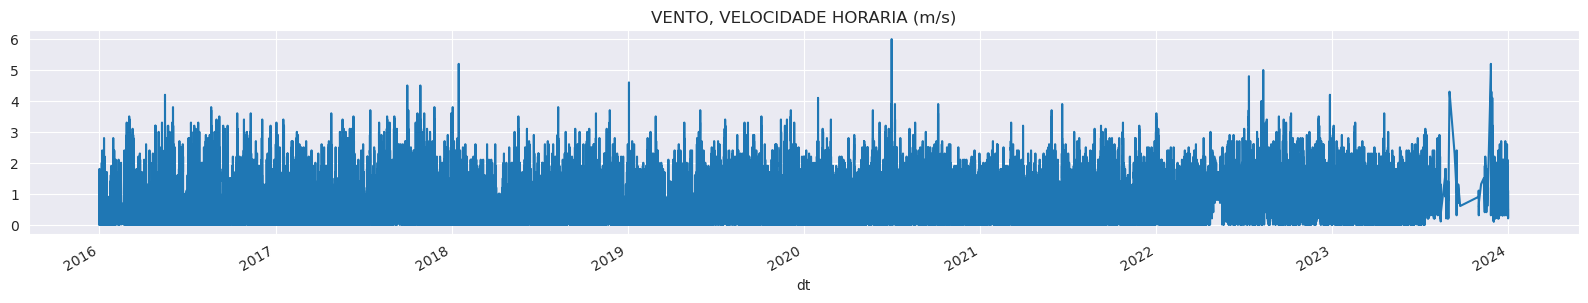

In [212]:

cleaned_weather_df = weather_df.copy()

for col in cleaned_weather_df.columns:
    cleaned_weather_df[col] = cleaned_weather_df[col].apply(lambda x: x if x > -900 else np.nan).interpolate(method="linear")

    cleaned_weather_df[col].plot(figsize=(20, 3), title=col)
    plt.title(col)
    plt.show()

#cleaned_weather_df.dropna(inplace=True)

# Análise de Correlação

               PREC_HOR  PRES_EST_HOR  PRES_MAX_ANT  PRES_MIN_ANT  RAD_GLOB  \
PREC_HOR       1.000000     -0.058609     -0.057579     -0.067870 -0.094685   
PRES_EST_HOR  -0.058609      1.000000      0.997100      0.997248  0.005969   
PRES_MAX_ANT  -0.057579      0.997100      1.000000      0.997756  0.032162   
PRES_MIN_ANT  -0.067870      0.997248      0.997756      1.000000  0.024756   
RAD_GLOB      -0.094685      0.005969      0.032162      0.024756  1.000000   
TEMP_AR_HOR   -0.041385     -0.460130     -0.445367     -0.450198  0.591475   
TEMP_ORV       0.089938     -0.546012     -0.546322     -0.546772  0.079090   
TEMP_MAX_ANT  -0.027761     -0.455504     -0.441343     -0.446028  0.584889   
TEMP_MIN_ANT  -0.027621     -0.490250     -0.476256     -0.480126  0.526472   
ORV_MAX_ANT    0.092051     -0.545204     -0.543015     -0.544480  0.166559   
ORV_MIN_ANT    0.100382     -0.538702     -0.541164     -0.540645 -0.014537   
UMID_MAX_ANT   0.145736      0.042873      0.024583 

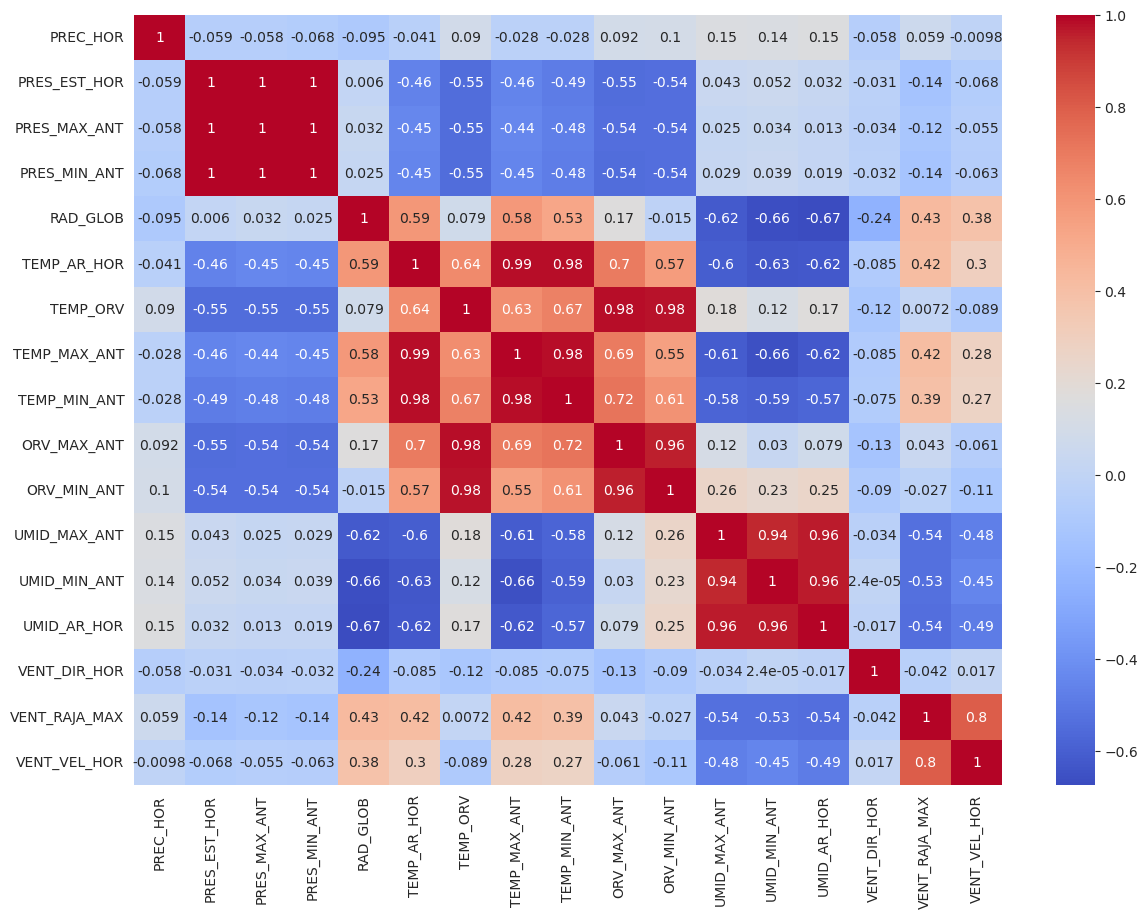

In [193]:
import seaborn as sns

"""
['Alface Americana - Roça',
 'Alface Crespa - Roça',
 'Alface Lisa - Roça',
 'Alface Americana - Atacado',
 'Alface Crespa - Atacado',
 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)',
 'c',
 'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
 'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
 'RADIACAO GLOBAL (Kj/m²)',
 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
 'TEMPERATURA DO PONTO DE ORVALHO (°C)',
 'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
 'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
 'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
 'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
 'UMIDADE RELATIVA DO AR, HORARIA (%)',
 'VENTO, DIREÇÃO HORARIA (gr) (° (gr))',
 'VENTO, RAJADA MAXIMA (m/s)',
 'VENTO, VELOCIDADE HORARIA (m/s)']
"""
rename_dict = {
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'PREC_HOR',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': 'PRES_EST_HOR',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)': 'PRES_MAX_ANT',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)': 'PRES_MIN_ANT',
    'RADIACAO GLOBAL (Kj/m²)': 'RAD_GLOB',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TEMP_AR_HOR',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)': 'TEMP_ORV',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TEMP_MAX_ANT',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TEMP_MIN_ANT',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)': 'ORV_MAX_ANT',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)': 'ORV_MIN_ANT',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)': 'UMID_MAX_ANT',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)': 'UMID_MIN_ANT',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'UMID_AR_HOR',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))': 'VENT_DIR_HOR',
    'VENTO, RAJADA MAXIMA (m/s)': 'VENT_RAJA_MAX',
    'VENTO, VELOCIDADE HORARIA (m/s)': 'VENT_VEL_HOR'
}
cleaned_weather_df.rename(columns=rename_dict, inplace=True)

# Compute correlation matrix
co_mtx = cleaned_weather_df.corr()

# Print correlation matrix
print(co_mtx)
plt.figure(figsize=(14, 10))
# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="coolwarm", annot=True)

# Display heatmap
plt.show()



In [194]:
cleaned_weather_df.drop(columns=['PRES_EST_HOR','PRES_MAX_ANT', 'TEMP_MIN_ANT', 'TEMP_MAX_ANT', 'ORV_MIN_ANT','ORV_MAX_ANT','UMID_MAX_ANT', 'UMID_MIN_ANT', 'VENT_RAJA_MAX'], inplace=True)



              PREC_HOR  PRES_MIN_ANT  RAD_GLOB  TEMP_AR_HOR  TEMP_ORV  \
PREC_HOR      1.000000     -0.067870 -0.094685    -0.041385  0.089938   
PRES_MIN_ANT -0.067870      1.000000  0.024756    -0.450198 -0.546772   
RAD_GLOB     -0.094685      0.024756  1.000000     0.591475  0.079090   
TEMP_AR_HOR  -0.041385     -0.450198  0.591475     1.000000  0.643970   
TEMP_ORV      0.089938     -0.546772  0.079090     0.643970  1.000000   
UMID_AR_HOR   0.152648      0.018635 -0.674677    -0.624628  0.171565   
VENT_DIR_HOR -0.058496     -0.032409 -0.239817    -0.084694 -0.118093   
VENT_VEL_HOR -0.009759     -0.063407  0.381981     0.297590 -0.089184   

              UMID_AR_HOR  VENT_DIR_HOR  VENT_VEL_HOR  
PREC_HOR         0.152648     -0.058496     -0.009759  
PRES_MIN_ANT     0.018635     -0.032409     -0.063407  
RAD_GLOB        -0.674677     -0.239817      0.381981  
TEMP_AR_HOR     -0.624628     -0.084694      0.297590  
TEMP_ORV         0.171565     -0.118093     -0.089184  
UMID_A

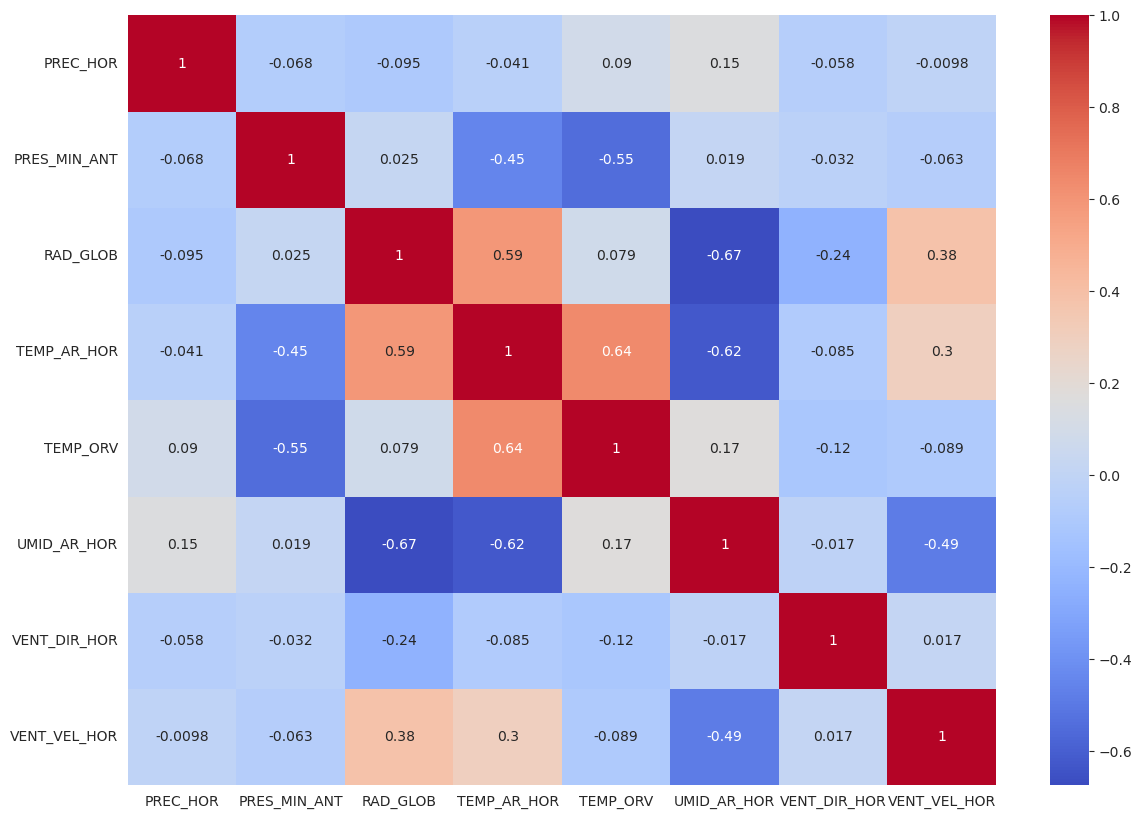

In [195]:
# Compute correlation matrix
co_mtx = cleaned_weather_df.corr()

# Print correlation matrix
print(co_mtx)
plt.figure(figsize=(14, 10))
# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="coolwarm", annot=True)

# Display heatmap
plt.show()

In [196]:
cleaned_weather_df.index = pd.to_datetime(cleaned_weather_df.index, utc=True)
resampled_cleaned_weather_df = pd.DataFrame(index=cleaned_weather_df.resample('W').sum().index)
resampled_cleaned_weather_df

""
dt
2016-01-03 00:00:00+00:00
2016-01-10 00:00:00+00:00
2016-01-17 00:00:00+00:00
2016-01-24 00:00:00+00:00
2016-01-31 00:00:00+00:00
...
2023-12-03 00:00:00+00:00
2023-12-10 00:00:00+00:00
2023-12-17 00:00:00+00:00


array([<Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>, <Axes: xlabel='dt'>,
       <Axes: xlabel='dt'>, <Axes: xlabel='dt'>], dtype=object)

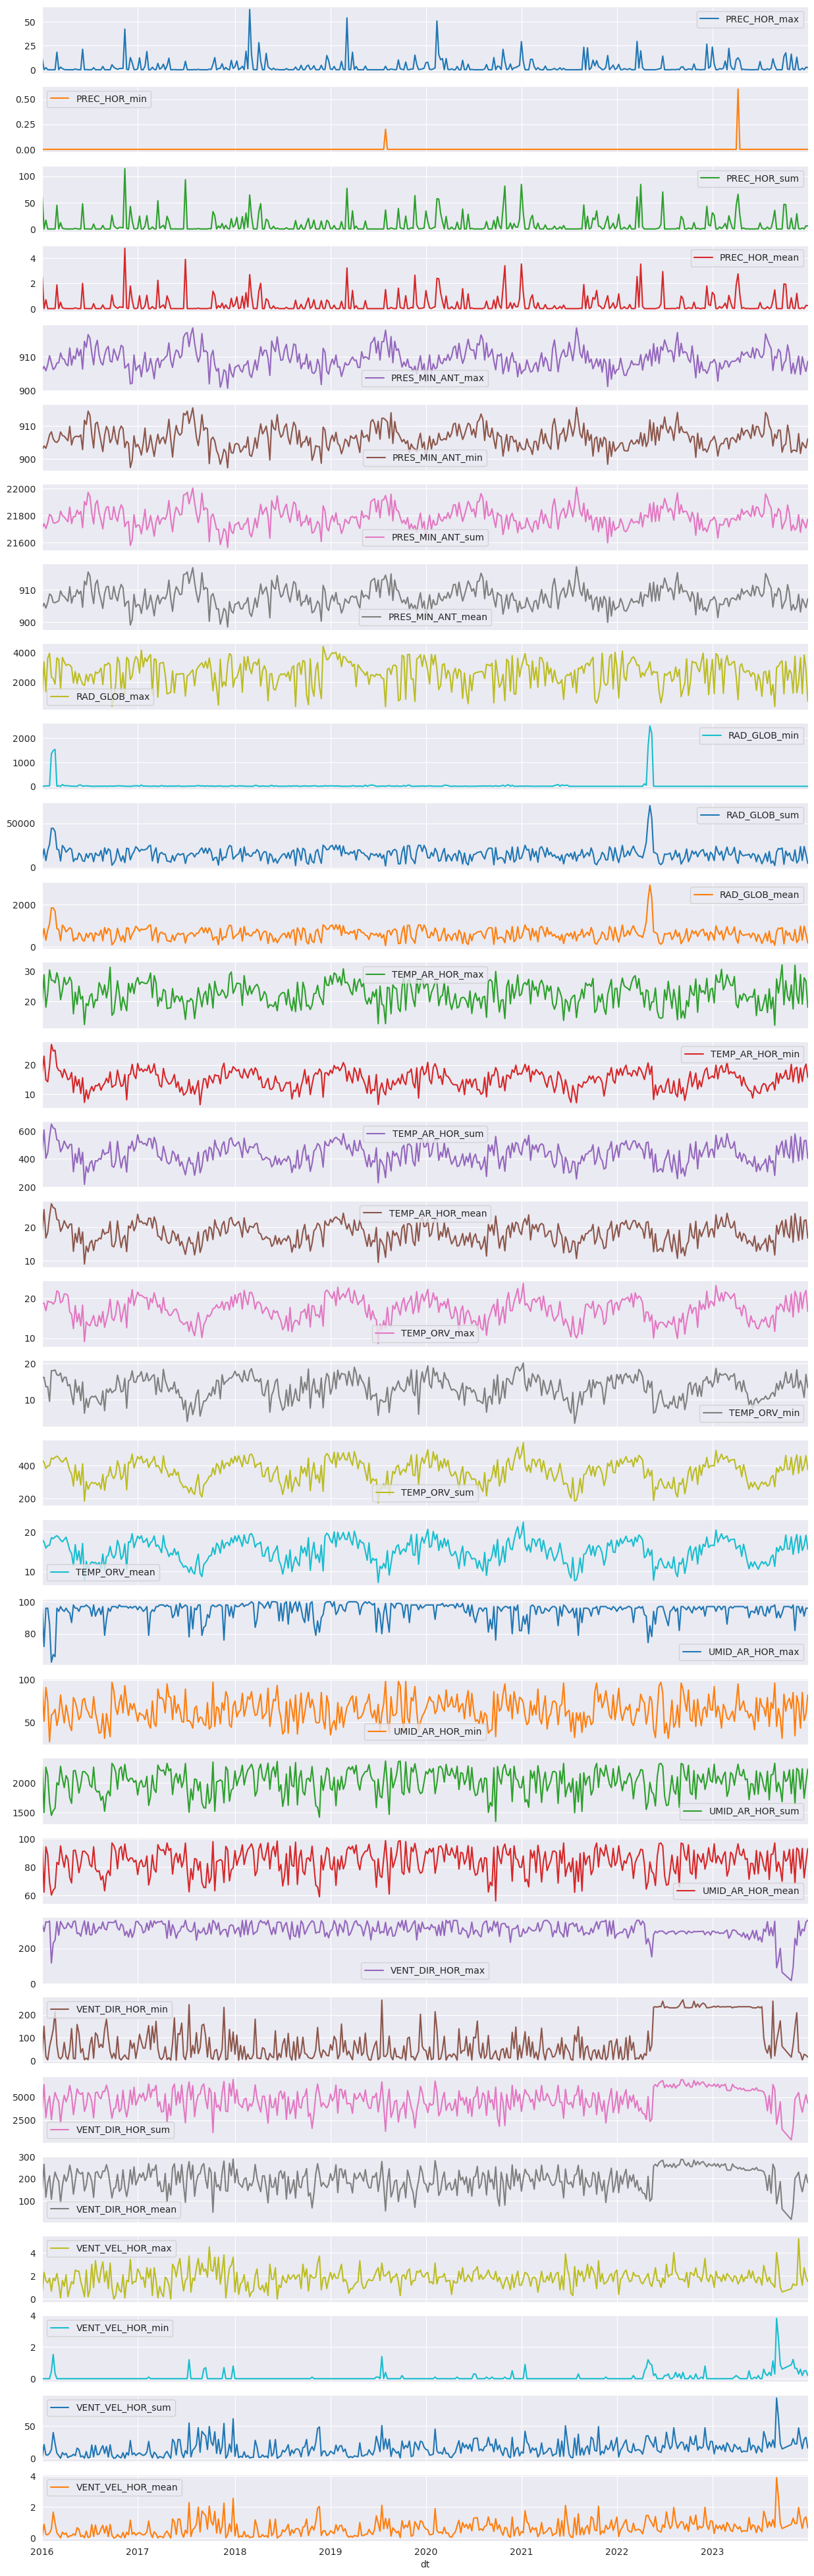

In [197]:

for col in cleaned_weather_df.columns:
    resampled_col = cleaned_weather_df[col].resample('D')
    #resampled_cleaned_weather_df[col] = resampled_col
    resampled_cleaned_weather_df[f'{col}_max'] = resampled_col.max()
    resampled_cleaned_weather_df[f'{col}_min'] = resampled_col.min()
    resampled_cleaned_weather_df[f'{col}_sum'] = resampled_col.sum()
    resampled_cleaned_weather_df[f'{col}_mean'] = resampled_col.mean()
    #resampled_cleaned_weather_df[f'{col}_std'] = resampled_col.std()
    #resampled_cleaned_weather_df[f'{col}_var'] = resampled_col.var()

def plot_col_variants(col_name):
    #resampled_cleaned_weather_df[f'{col_name}'].plot()
    plt.figure(figsize=(14, 10))
    ax = plt.subplot(5, 1, 1)
    resampled_cleaned_weather_df[f'{col_name}_max'].plot()
    resampled_cleaned_weather_df[f'{col_name}_min'].plot()
    resampled_cleaned_weather_df[f'{col_name}_sum'].plot()
    resampled_cleaned_weather_df[f'{col_name}_mean'].plot()
    resampled_cleaned_weather_df[f'{col_name}_std'].plot()
    resampled_cleaned_weather_df[f'{col_name}_var'].plot()
    plt.show()

resampled_cleaned_weather_df.plot(figsize=(15, 50), subplots=True)


In [198]:
from datetime import  timedelta
aligned_dates = [price_df.index[0] + timedelta(weeks=i) for i in range(len(price_df))]
aligned_dates

[Timestamp('2016-04-22 00:00:00+0000', tz='UTC'),
 Timestamp('2016-04-29 00:00:00+0000', tz='UTC'),
 Timestamp('2016-05-06 00:00:00+0000', tz='UTC'),
 Timestamp('2016-05-13 00:00:00+0000', tz='UTC'),
 Timestamp('2016-05-20 00:00:00+0000', tz='UTC'),
 Timestamp('2016-05-27 00:00:00+0000', tz='UTC'),
 Timestamp('2016-06-03 00:00:00+0000', tz='UTC'),
 Timestamp('2016-06-10 00:00:00+0000', tz='UTC'),
 Timestamp('2016-06-17 00:00:00+0000', tz='UTC'),
 Timestamp('2016-06-24 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-01 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-08 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-15 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-22 00:00:00+0000', tz='UTC'),
 Timestamp('2016-07-29 00:00:00+0000', tz='UTC'),
 Timestamp('2016-08-05 00:00:00+0000', tz='UTC'),
 Timestamp('2016-08-12 00:00:00+0000', tz='UTC'),
 Timestamp('2016-08-19 00:00:00+0000', tz='UTC'),
 Timestamp('2016-08-26 00:00:00+0000', tz='UTC'),
 Timestamp('2016-09-02 00:00:00+0000', tz='UTC'),


In [199]:
resampled_cleaned_weather_df

,PREC_HOR_max,PREC_HOR_min,PREC_HOR_sum,PREC_HOR_mean,PRES_MIN_ANT_max,PRES_MIN_ANT_min,PRES_MIN_ANT_sum,PRES_MIN_ANT_mean,RAD_GLOB_max,RAD_GLOB_min,...,UMID_AR_HOR_sum,UMID_AR_HOR_mean,VENT_DIR_HOR_max,VENT_DIR_HOR_min,VENT_DIR_HOR_sum,VENT_DIR_HOR_mean,VENT_VEL_HOR_max,VENT_VEL_HOR_min,VENT_VEL_HOR_sum,VENT_VEL_HOR_mean
dt,,,,,,,,,,,,,,,,,,,,,
2016-01-03 00:00:00+00:00,11.8,0.0,61.4,2.558333,906.2,902.9,21710.1,904.587500,1250.2,0.000000,...,2268.0,94.500000,337.0,30.0,3618.0,150.750000,0.6,0.0,2.2,0.091667
2016-01-10 00:00:00+00:00,0.0,0.0,0.0,0.000000,907.2,903.9,21740.6,905.858333,3360.3,9.500000,...,1498.0,62.416667,296.0,150.0,6364.0,265.166667,2.3,0.0,21.3,0.887500
2016-01-17 00:00:00+00:00,2.2,0.0,16.8,0.700000,905.9,903.2,21705.5,904.395833,1349.7,13.781818,...,2263.0,94.291667,351.0,17.0,2783.0,115.958333,1.6,0.0,5.5,0.229167
2016-01-24 00:00:00+00:00,0.0,0.0,0.0,0.000000,907.7,905.0,21746.2,906.091667,3610.3,18.254545,...,2130.0,88.750000,349.0,2.0,4317.0,179.875000,1.4,0.0,4.9,0.204167
2016-01-31 00:00:00+00:00,0.0,0.0,0.0,0.000000,910.4,907.3,21810.1,908.754167,3947.7,15.800000,...,1667.0,69.458333,355.0,60.0,5107.0,212.791667,1.8,0.0,7.7,0.320833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-03 00:00:00+00:00,0.0,0.0,0.0,0.000000,904.8,901.6,21676.1,903.170833,3648.2,0.000000,...,1895.0,78.958333,272.0,32.0,4178.0,174.083333,2.2,0.6,29.2,1.216667
2023-12-10 00:00:00+00:00,1.6,0.0,1.8,0.075000,910.1,905.0,21774.6,907.275000,1194.1,0.000000,...,2236.0,93.166667,309.0,2.0,3372.0,140.500000,1.2,0.2,14.8,0.616667
2023-12-17 00:00:00+00:00,0.0,0.0,0.0,0.000000,907.5,904.0,21743.1,905.962500,3829.1,0.000000,...,1738.0,72.416667,299.0,27.0,4384.0,182.666667,2.7,0.5,29.4,1.225000


In [200]:
resampled_cleaned_weather_df.index

DatetimeIndex(['2016-01-03 00:00:00+00:00', '2016-01-10 00:00:00+00:00',
               '2016-01-17 00:00:00+00:00', '2016-01-24 00:00:00+00:00',
               '2016-01-31 00:00:00+00:00', '2016-02-07 00:00:00+00:00',
               '2016-02-14 00:00:00+00:00', '2016-02-21 00:00:00+00:00',
               '2016-02-28 00:00:00+00:00', '2016-03-06 00:00:00+00:00',
               ...
               '2023-10-29 00:00:00+00:00', '2023-11-05 00:00:00+00:00',
               '2023-11-12 00:00:00+00:00', '2023-11-19 00:00:00+00:00',
               '2023-11-26 00:00:00+00:00', '2023-12-03 00:00:00+00:00',
               '2023-12-10 00:00:00+00:00', '2023-12-17 00:00:00+00:00',
               '2023-12-24 00:00:00+00:00', '2023-12-31 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='dt', length=418, freq='W-SUN')

In [201]:
#resampled_cleaned_weather_df.index = resampled_cleaned_weather_df.index.isocalendar().week

In [202]:
resampled_cleaned_weather_df['week-year'] = resampled_cleaned_weather_df.index.isocalendar().apply(lambda x: f"{x['week']}-{x['year']}", axis=1)
resampled_cleaned_weather_df

,PREC_HOR_max,PREC_HOR_min,PREC_HOR_sum,PREC_HOR_mean,PRES_MIN_ANT_max,PRES_MIN_ANT_min,PRES_MIN_ANT_sum,PRES_MIN_ANT_mean,RAD_GLOB_max,RAD_GLOB_min,...,UMID_AR_HOR_mean,VENT_DIR_HOR_max,VENT_DIR_HOR_min,VENT_DIR_HOR_sum,VENT_DIR_HOR_mean,VENT_VEL_HOR_max,VENT_VEL_HOR_min,VENT_VEL_HOR_sum,VENT_VEL_HOR_mean,week-year
dt,,,,,,,,,,,,,,,,,,,,,
2016-01-03 00:00:00+00:00,11.8,0.0,61.4,2.558333,906.2,902.9,21710.1,904.587500,1250.2,0.000000,...,94.500000,337.0,30.0,3618.0,150.750000,0.6,0.0,2.2,0.091667,53-2015
2016-01-10 00:00:00+00:00,0.0,0.0,0.0,0.000000,907.2,903.9,21740.6,905.858333,3360.3,9.500000,...,62.416667,296.0,150.0,6364.0,265.166667,2.3,0.0,21.3,0.887500,1-2016
2016-01-17 00:00:00+00:00,2.2,0.0,16.8,0.700000,905.9,903.2,21705.5,904.395833,1349.7,13.781818,...,94.291667,351.0,17.0,2783.0,115.958333,1.6,0.0,5.5,0.229167,2-2016
2016-01-24 00:00:00+00:00,0.0,0.0,0.0,0.000000,907.7,905.0,21746.2,906.091667,3610.3,18.254545,...,88.750000,349.0,2.0,4317.0,179.875000,1.4,0.0,4.9,0.204167,3-2016
2016-01-31 00:00:00+00:00,0.0,0.0,0.0,0.000000,910.4,907.3,21810.1,908.754167,3947.7,15.800000,...,69.458333,355.0,60.0,5107.0,212.791667,1.8,0.0,7.7,0.320833,4-2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-03 00:00:00+00:00,0.0,0.0,0.0,0.000000,904.8,901.6,21676.1,903.170833,3648.2,0.000000,...,78.958333,272.0,32.0,4178.0,174.083333,2.2,0.6,29.2,1.216667,48-2023
2023-12-10 00:00:00+00:00,1.6,0.0,1.8,0.075000,910.1,905.0,21774.6,907.275000,1194.1,0.000000,...,93.166667,309.0,2.0,3372.0,140.500000,1.2,0.2,14.8,0.616667,49-2023
2023-12-17 00:00:00+00:00,0.0,0.0,0.0,0.000000,907.5,904.0,21743.1,905.962500,3829.1,0.000000,...,72.416667,299.0,27.0,4384.0,182.666667,2.7,0.5,29.4,1.225000,50-2023


In [203]:
price_df['week-year'] = price_df.index.isocalendar().apply(lambda x: f"{x['week']}-{x['year']}", axis=1)
price_df

,Alface Americana - Roça,Alface Crespa - Roça,Alface Lisa - Roça,Alface Americana - Atacado,Alface Crespa - Atacado,week-year
dt,,,,,,
2016-04-22 00:00:00+00:00,0.592500,0.616500,0.618000,NaN,NaN,16-2016
2016-04-29 00:00:00+00:00,1.000000,0.426111,0.500000,NaN,NaN,17-2016
2016-05-06 00:00:00+00:00,1.041667,0.437778,0.479444,NaN,NaN,18-2016
2016-05-13 00:00:00+00:00,1.055833,0.430556,0.430556,NaN,NaN,19-2016
2016-05-20 00:00:00+00:00,0.764167,0.444444,0.398333,NaN,NaN,20-2016
...,...,...,...,...,...,...
2024-02-29 00:00:00+00:00,1.333333,1.008333,1.008333,NaN,NaN,9-2024
2024-03-07 00:00:00+00:00,1.333333,1.008333,1.008333,NaN,NaN,10-2024
2024-03-14 00:00:00+00:00,1.383333,0.938750,0.938750,NaN,NaN,11-2024


In [204]:
resampled_cleaned_weather_df.reset_index(inplace=True)
resampled_cleaned_weather_df.drop('dt', axis=1, inplace=True)

In [205]:
price_weather_df = pd.merge(price_df.reset_index(), resampled_cleaned_weather_df, on='week-year', how='left')
price_weather_df

,dt,Alface Americana - Roça,Alface Crespa - Roça,Alface Lisa - Roça,Alface Americana - Atacado,Alface Crespa - Atacado,week-year,PREC_HOR_max,PREC_HOR_min,PREC_HOR_sum,...,UMID_AR_HOR_sum,UMID_AR_HOR_mean,VENT_DIR_HOR_max,VENT_DIR_HOR_min,VENT_DIR_HOR_sum,VENT_DIR_HOR_mean,VENT_VEL_HOR_max,VENT_VEL_HOR_min,VENT_VEL_HOR_sum,VENT_VEL_HOR_mean
0,2016-04-22 00:00:00+00:00,0.592500,0.616500,0.618000,NaN,NaN,16-2016,0.0,0.0,0.0,...,1652.0,68.833333,316.0,140.0,5259.0,219.125000,1.5,0.0,3.6,0.150000
1,2016-04-29 00:00:00+00:00,1.000000,0.426111,0.500000,NaN,NaN,17-2016,0.0,0.0,0.0,...,2200.0,91.666667,353.0,9.0,3111.0,129.625000,1.3,0.0,6.2,0.258333
2,2016-05-06 00:00:00+00:00,1.041667,0.437778,0.479444,NaN,NaN,18-2016,0.8,0.0,1.4,...,2207.0,91.958333,355.0,7.0,4536.0,189.000000,2.5,0.0,4.2,0.175000
3,2016-05-13 00:00:00+00:00,1.055833,0.430556,0.430556,NaN,NaN,19-2016,0.2,0.0,0.2,...,2044.0,85.166667,284.0,158.0,5899.0,245.791667,2.4,0.0,15.9,0.662500
4,2016-05-20 00:00:00+00:00,0.764167,0.444444,0.398333,NaN,NaN,20-2016,0.0,0.0,0.0,...,1826.0,76.083333,287.0,119.0,5453.0,227.208333,2.4,0.0,13.3,0.554167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,2024-02-29 00:00:00+00:00,1.333333,1.008333,1.008333,NaN,NaN,9-2024,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
395,2024-03-07 00:00:00+00:00,1.333333,1.008333,1.008333,NaN,NaN,10-2024,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
396,2024-03-14 00:00:00+00:00,1.383333,0.938750,0.938750,NaN,NaN,11-2024,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397,2024-03-21 00:00:00+00:00,1.583333,1.033333,1.033333,NaN,NaN,12-2024,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [206]:
price_weather_df.set_index('dt', inplace=True)
price_weather_df.drop('week-year', axis=1, inplace=True)

<Axes: xlabel='dt'>

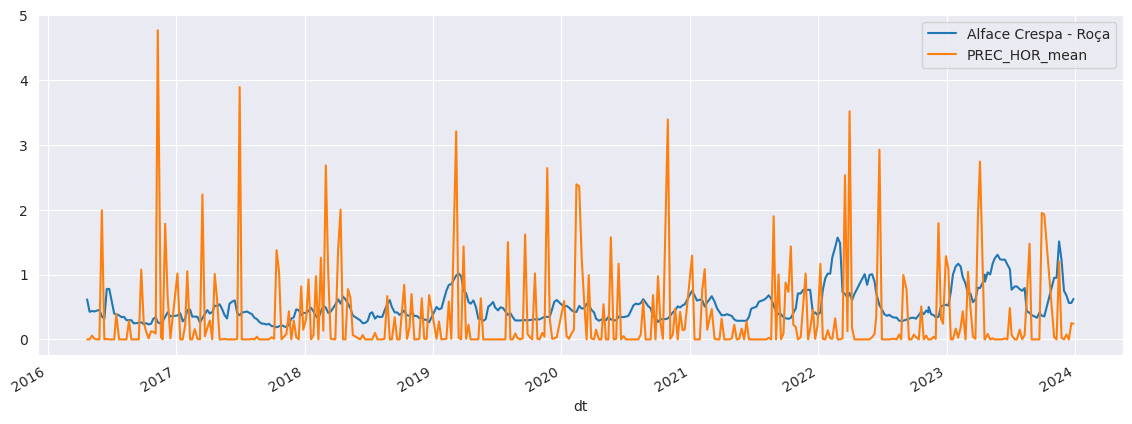

In [207]:
price_weather_df = price_weather_df[price_weather_df.index <= '2023-12-28']
price_weather_df[['Alface Crespa - Roça', 'PREC_HOR_mean']].plot(figsize=(14, 5))


                            Alface Americana - Roça  Alface Crespa - Roça  \
Alface Americana - Roça                    1.000000              0.864011   
Alface Crespa - Roça                       0.864011              1.000000   
Alface Lisa - Roça                         0.862489              0.988119   
Alface Americana - Atacado                      NaN                   NaN   
Alface Crespa - Atacado                         NaN                   NaN   
PREC_HOR_max                               0.027754              0.006521   
PREC_HOR_min                               0.011559              0.047100   
PREC_HOR_sum                               0.001103             -0.037047   
PREC_HOR_mean                              0.001103             -0.037047   
PRES_MIN_ANT_max                          -0.093789             -0.055434   
PRES_MIN_ANT_min                          -0.078185             -0.031360   
PRES_MIN_ANT_sum                          -0.081519             -0.039712   

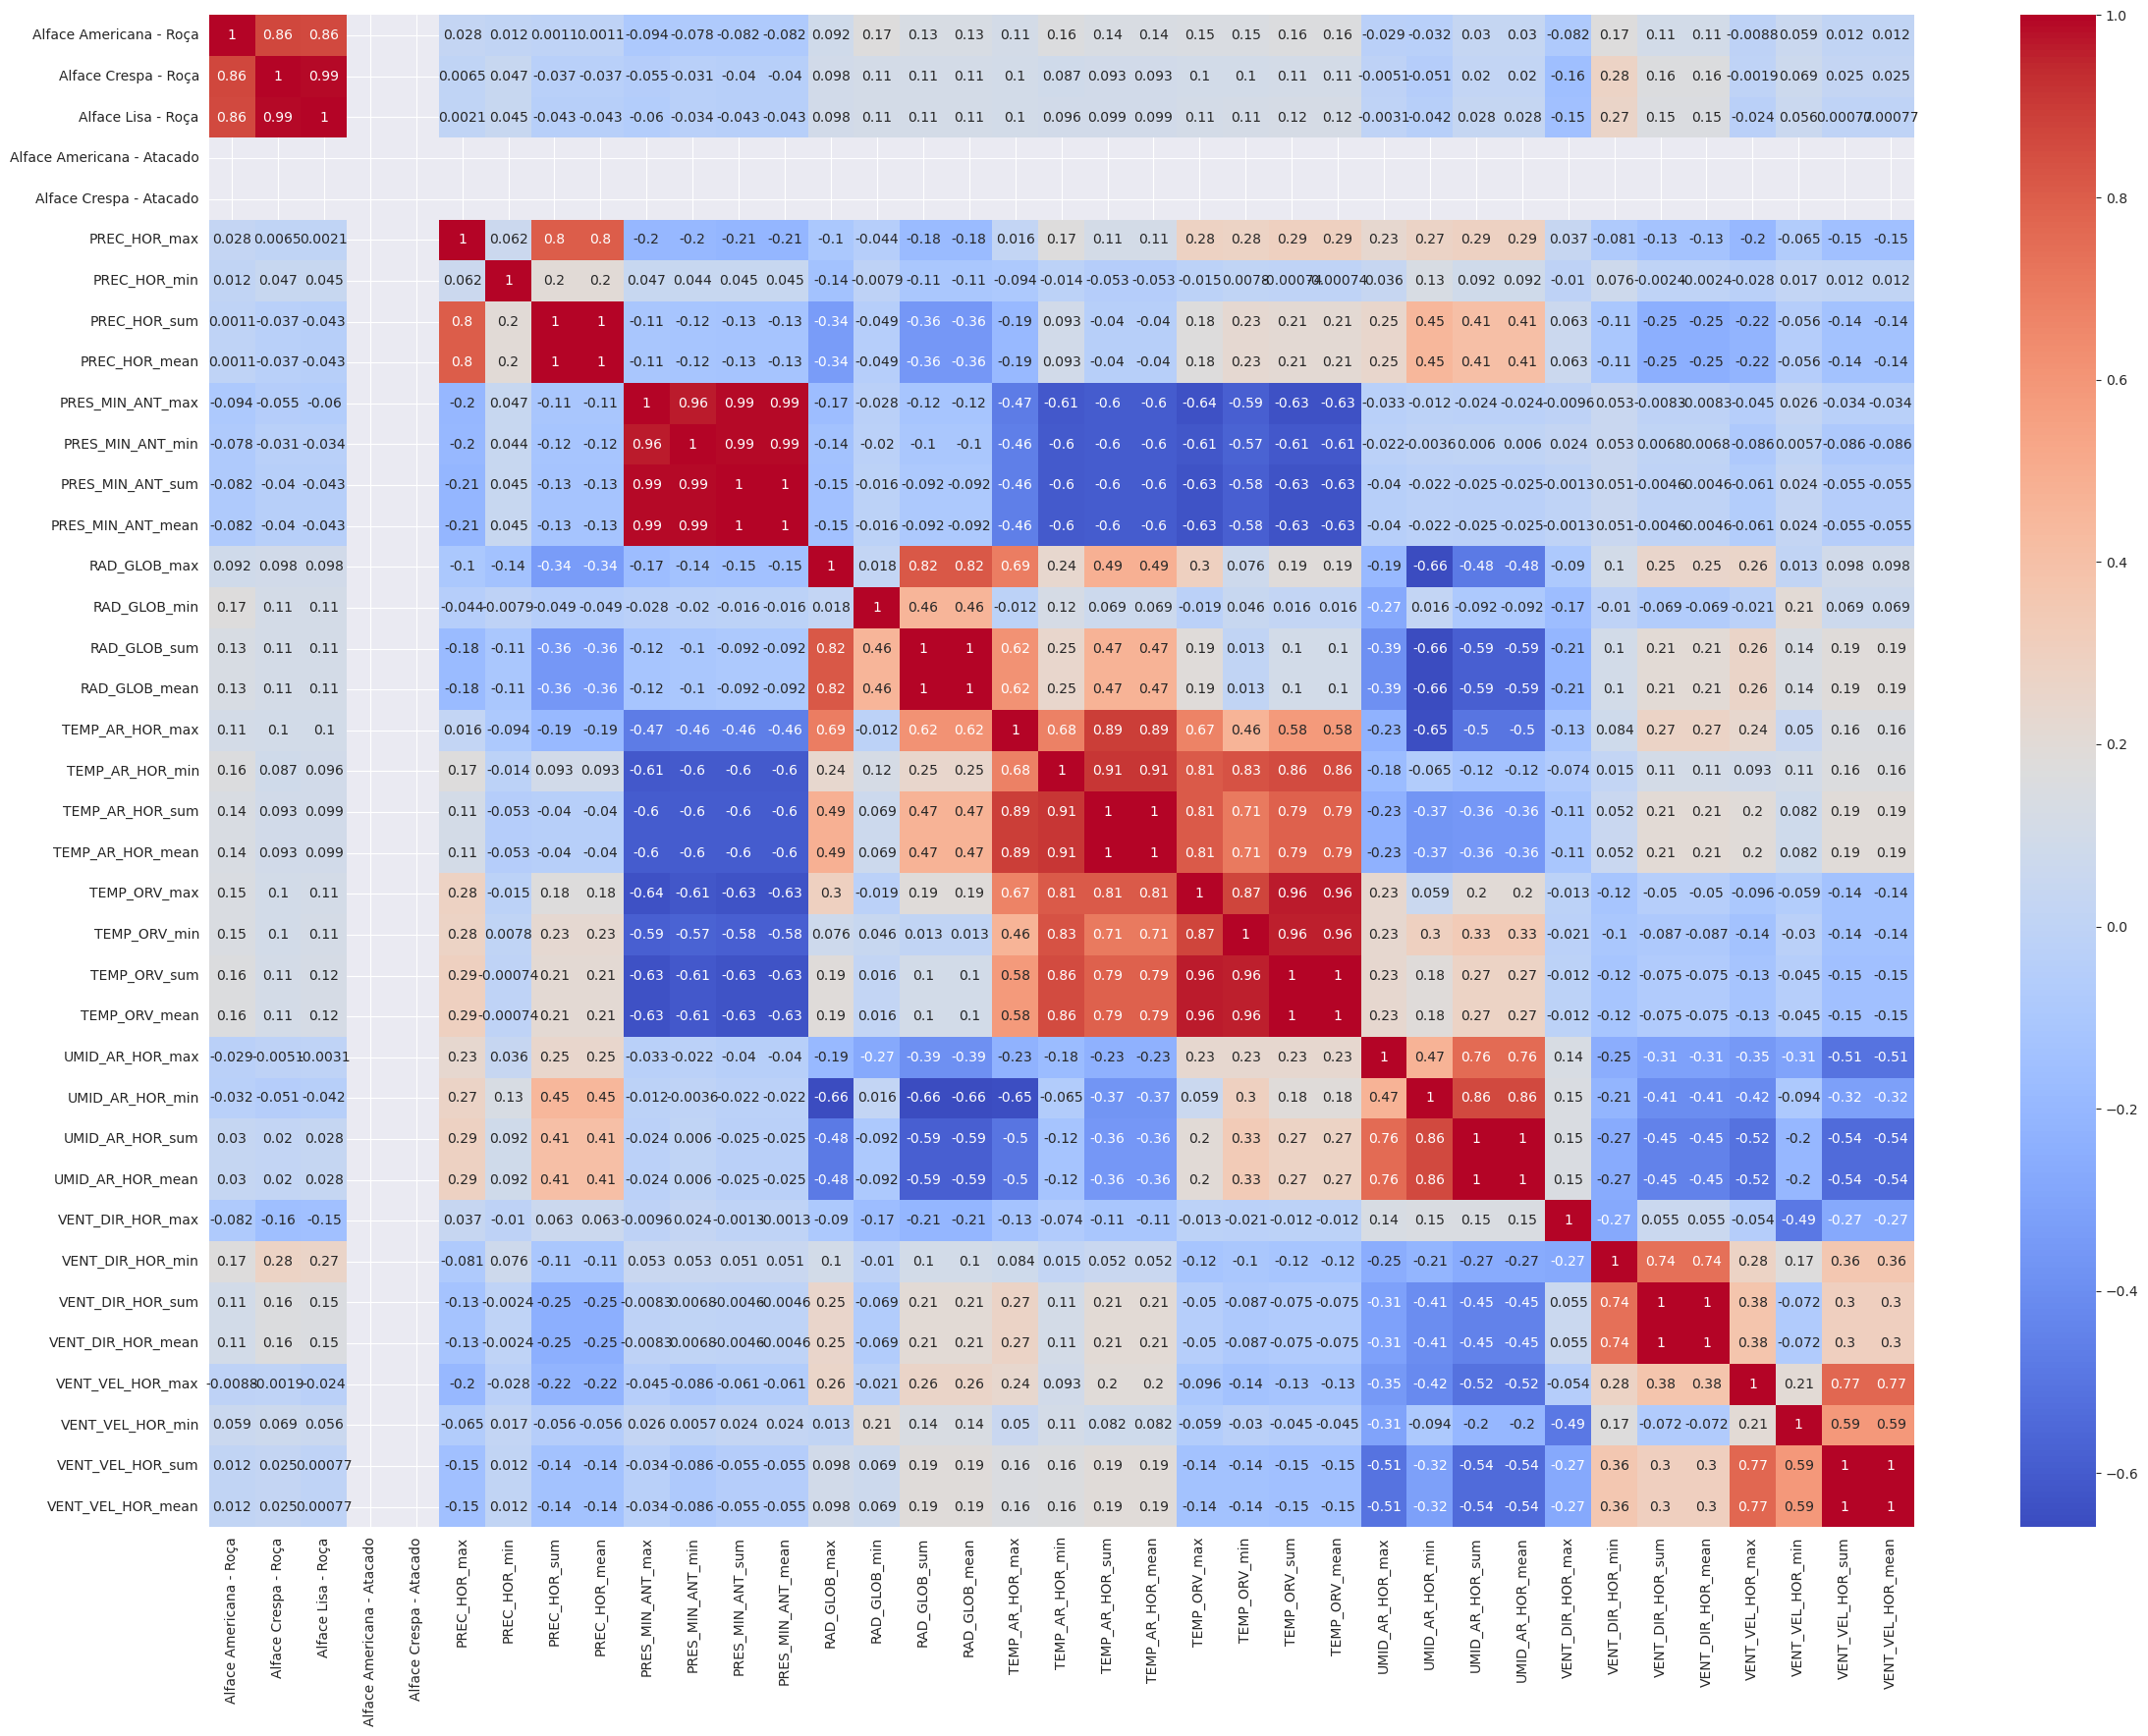

In [208]:
# Compute correlation matrix
co_mtx = price_weather_df.corr()

# Print correlation matrix
print(co_mtx)
plt.figure(figsize=(28, 20))
# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="coolwarm", annot=True)

# Display heatmap
plt.show()

In [209]:
resampled_cleaned_weather_df.isna().sum()

PREC_HOR_max         0
PREC_HOR_min         0
PREC_HOR_sum         0
PREC_HOR_mean        0
PRES_MIN_ANT_max     0
PRES_MIN_ANT_min     0
PRES_MIN_ANT_sum     0
PRES_MIN_ANT_mean    0
RAD_GLOB_max         0
RAD_GLOB_min         0
RAD_GLOB_sum         0
RAD_GLOB_mean        0
TEMP_AR_HOR_max      0
TEMP_AR_HOR_min      0
TEMP_AR_HOR_sum      0
TEMP_AR_HOR_mean     0
TEMP_ORV_max         0
TEMP_ORV_min         0
TEMP_ORV_sum         0
TEMP_ORV_mean        0
UMID_AR_HOR_max      0
UMID_AR_HOR_min      0
UMID_AR_HOR_sum      0
UMID_AR_HOR_mean     0
VENT_DIR_HOR_max     0
VENT_DIR_HOR_min     0
VENT_DIR_HOR_sum     0
VENT_DIR_HOR_mean    0
VENT_VEL_HOR_max     0
VENT_VEL_HOR_min     0
VENT_VEL_HOR_sum     0
VENT_VEL_HOR_mean    0
week-year            0
dtype: int64

In [213]:
interest_cols = ['Alface Crespa - Roça']
shift_cols = price_weather_df.columns.tolist()
#shift_cols = ['RADIACAO GLOBAL (Kj/m²)_max']

with open('correlation/correlation.csv', 'w') as f:
    f.write('column,correlated_to,max_correlation\n')

for col in shift_cols:
    temp_df = pd.DataFrame()
    temp_df.index = price_weather_df.index

    for i_col in interest_cols:
        temp_df[i_col] = price_weather_df[i_col]

    temp_df[0] = price_weather_df[col]
    for i in range(1, 110):
        temp_df[i] = temp_df[0].shift(i)
        temp_df = temp_df.copy()

    corr = temp_df.corr(method="spearman")
    corr = corr.iloc[1:]
    corr = corr[interest_cols]
    corr = corr[interest_cols].apply(lambda x: x.abs())
    max_corr = corr[interest_cols].max().values[0]
    corr.index.names = [f'Shifted: {col}']
    corr.columns = [f'Corr. with {c}' for c in interest_cols]


    plt.tight_layout()

    corr.plot(figsize=(10, 3), ylim=(0, 1), title=f'Correlation between {col} and {interest_cols[0]}', grid=True)

    vertical_lines_1 = [i for i in range(0, 110, 26)]
    for v in vertical_lines_1:
        plt.axvline(x = v, color = 'r', label = 'axvline - full height')
        plt.axvline(x = v+7, color = 'b', label = 'axvline - full height')
        plt.axvline(x = v+10, color = 'g', label = 'axvline - full height')

    with open('correlation/correlation.csv', 'a') as f:
        f.write(f'\"{col}\",\"{interest_cols[0]}\",{max_corr}\n')

    plt.savefig(f'correlation/{col}.png', bbox_inches='tight')
    plt.close()

<Figure size 640x480 with 0 Axes>

In [211]:
#price_weather_df = resampled_cleaned_weather_df.copy()


---